# ChestMNIST: kNN vs Linear Probe Results

Results-only comparison of the completed full-data ChestMNIST runs.

- kNN headline rows select the best full-reference `k` and threshold by macro F1.
- Linear-probe headline rows use the saved validation-selected epoch, learning rate,
  weight decay, and threshold.
- Efficiency uses the saved phase-aware timing fields. Actual wall time is shown
  separately because not every notebook operation belongs to a counted method phase.

These are validation-selected results, not an unbiased held-out final test estimate.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

project_root = Path.cwd()
if not (project_root / "outputs" / "chestmnist").exists():
    project_root = project_root.parent

output_root = project_root / "outputs" / "chestmnist"
print("Project root:", project_root)
print("Results root:", output_root)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

Project root: c:\Users\vasko\Downloads\xai\project
Results root: c:\Users\vasko\Downloads\xai\project\outputs\chestmnist


In [2]:
model_order = [
    "dinov2_small_224",
    "dinov2_large_224",
    "dinov3_large_224",
    "stanford_dinov2_xray_224",
    "rad_dino_518",
]

display_names = {
    "dinov2_small_224": "DINOv2-S 224",
    "dinov2_large_224": "DINOv2-L 224",
    "dinov3_large_224": "DINOv3-L 224",
    "stanford_dinov2_xray_224": "Stanford X-ray DINOv2-B 224",
    "rad_dino_518": "RAD-DINO 518",
}

model_groups = {
    "dinov2_small_224": "Generic DINOv2",
    "dinov2_large_224": "Generic DINOv2",
    "dinov3_large_224": "Generic DINOv3",
    "stanford_dinov2_xray_224": "Medical/X-ray",
    "rad_dino_518": "Medical/X-ray",
}

group_colors = {
    "Generic DINOv2": "tab:blue",
    "Generic DINOv3": "tab:purple",
    "Medical/X-ray": "tab:green",
}
method_markers = {"kNN": "o", "Linear probe": "^"}
method_hatches = {"kNN": "", "Linear probe": "//"}

def read_metadata(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def selected_knn_row(summary_df):
    full_df = summary_df[summary_df["setting"] == "full"].copy()
    return full_df.sort_values(
        ["f1_macro_mean", "mean_auc_mean", "f1_micro_mean", "mean_accuracy_mean"],
        ascending=False,
    ).iloc[0]

headline_rows = []
per_class_frames = []
knn_full_grid_frames = []
linear_trial_frames = []
linear_history_frames = []
metadata_records = []

for run_name in model_order:
    knn_dir = output_root / "knn" / run_name
    linear_dir = output_root / "linear_probe" / run_name

    knn_summary = pd.read_csv(knn_dir / "summary.csv")
    knn_selected = selected_knn_row(knn_summary)
    knn_metadata = read_metadata(knn_dir / "metadata.json")
    knn_full_grid_frames.append(knn_summary[knn_summary["setting"] == "full"].copy())

    knn_per_class = pd.read_csv(knn_dir / "per_class_full.csv")
    knn_per_class = knn_per_class[
        (knn_per_class["setting"] == "full")
        & (knn_per_class["k"] == int(knn_selected["k"]))
        & np.isclose(knn_per_class["threshold"], float(knn_selected["threshold"]))
    ].copy()
    knn_per_class["method"] = "kNN"
    per_class_frames.append(knn_per_class)

    headline_rows.append(
        {
            "run_name": run_name,
            "method": "kNN",
            "mean_auc": knn_selected["mean_auc_mean"],
            "f1_macro": knn_selected["f1_macro_mean"],
            "f1_micro": knn_selected["f1_micro_mean"],
            "mean_accuracy": knn_selected["mean_accuracy_mean"],
            "exact_match_accuracy": knn_selected["exact_match_accuracy_mean"],
            "k": int(knn_selected["k"]),
            "threshold": float(knn_selected["threshold"]),
            "epoch": np.nan,
            "lr": np.nan,
            "weight_decay": np.nan,
            **{
                key: knn_metadata.get(key)
                for key in [
                    "total_params",
                    "trainable_params",
                    "trainable_param_fraction",
                    "feature_dim",
                    "feature_storage_mb",
                    "feature_extraction_seconds",
                    "adaptation_seconds",
                    "inference_or_eval_seconds",
                    "threshold_search_seconds",
                    "efficiency_counted_seconds",
                    "actual_wall_seconds",
                    "peak_gpu_memory_mb",
                ]
            },
        }
    )
    metadata_records.append({"run_name": run_name, "method": "kNN", **knn_metadata})

    linear_summary = pd.read_csv(linear_dir / "summary.csv").iloc[0]
    linear_metadata = read_metadata(linear_dir / "metadata.json")
    linear_per_class = pd.read_csv(linear_dir / "per_class.csv")
    linear_per_class["method"] = "Linear probe"
    per_class_frames.append(linear_per_class)
    linear_trial_frames.append(pd.read_csv(linear_dir / "trials.csv"))
    linear_history_frames.append(pd.read_csv(linear_dir / "history.csv"))

    headline_rows.append(
        {
            "run_name": run_name,
            "method": "Linear probe",
            "mean_auc": linear_summary["mean_auc"],
            "f1_macro": linear_summary["f1_macro"],
            "f1_micro": linear_summary["f1_micro"],
            "mean_accuracy": linear_summary["mean_accuracy"],
            "exact_match_accuracy": linear_summary["exact_match_accuracy"],
            "k": np.nan,
            "threshold": float(linear_summary["threshold"]),
            "epoch": int(linear_summary["epoch"]),
            "lr": float(linear_summary["lr"]),
            "weight_decay": float(linear_summary["weight_decay"]),
            **{
                key: linear_metadata.get(key)
                for key in [
                    "total_params",
                    "trainable_params",
                    "trainable_param_fraction",
                    "feature_dim",
                    "feature_storage_mb",
                    "feature_extraction_seconds",
                    "adaptation_seconds",
                    "inference_or_eval_seconds",
                    "threshold_search_seconds",
                    "efficiency_counted_seconds",
                    "actual_wall_seconds",
                    "peak_gpu_memory_mb",
                ]
            },
        }
    )
    metadata_records.append(
        {"run_name": run_name, "method": "Linear probe", **linear_metadata}
    )

headline_df = pd.DataFrame(headline_rows)
headline_df["display_name"] = headline_df["run_name"].map(display_names)
headline_df["model_group"] = headline_df["run_name"].map(model_groups)
headline_df["model_order"] = headline_df["run_name"].map(
    {name: idx for idx, name in enumerate(model_order)}
)

per_class_df = pd.concat(per_class_frames, ignore_index=True)
per_class_df["display_name"] = per_class_df["run_name"].map(display_names)
knn_full_grid_df = pd.concat(knn_full_grid_frames, ignore_index=True)
linear_trials_df = pd.concat(linear_trial_frames, ignore_index=True)
linear_history_df = pd.concat(linear_history_frames, ignore_index=True)
metadata_df = pd.DataFrame(metadata_records)

print("Headline rows:", len(headline_df))
print("Selected per-class rows:", len(per_class_df))
print("kNN full-grid rows:", len(knn_full_grid_df))
print("Linear-probe trial rows:", len(linear_trials_df))

Headline rows: 10
Selected per-class rows: 140
kNN full-grid rows: 440
Linear-probe trial rows: 17280


## Headline Comparison

One selected row per model and method. The selected hyperparameters are reported
alongside performance and efficiency so the comparison remains auditable.

In [3]:
headline_cols = [
    "display_name",
    "method",
    "mean_auc",
    "f1_macro",
    "f1_micro",
    "mean_accuracy",
    "exact_match_accuracy",
    "k",
    "epoch",
    "lr",
    "weight_decay",
    "threshold",
    "trainable_params",
    "efficiency_counted_seconds",
    "actual_wall_seconds",
    "peak_gpu_memory_mb",
]

headline_table_df = headline_df.sort_values(["model_order", "method"])[headline_cols]
headline_table_df

,display_name,method,mean_auc,f1_macro,f1_micro,mean_accuracy,exact_match_accuracy,k,epoch,lr,weight_decay,threshold,trainable_params,efficiency_counted_seconds,actual_wall_seconds,peak_gpu_memory_mb
1,DINOv2-S 224,Linear probe,0.719180,0.155708,0.278667,0.854017,0.133702,NaN,100.0,0.003,0.00000,0.10,5390,2409.883950,3597.922648,291.389160
0,DINOv2-S 224,kNN,0.609363,0.131099,0.210579,0.780513,0.055353,20.0,NaN,NaN,NaN,0.10,0,736.552050,738.949197,340.812012
3,DINOv2-L 224,Linear probe,0.730337,0.161204,0.250414,0.795239,0.056690,NaN,100.0,0.003,0.00100,0.07,14350,3934.074088,5088.123292,1427.511719
2,DINOv2-L 224,kNN,0.592239,0.124154,0.208523,0.783957,0.051787,20.0,NaN,NaN,NaN,0.10,0,2238.724719,2240.954770,1419.613281
5,DINOv3-L 224,Linear probe,0.734347,0.167396,0.284891,0.853100,0.159818,NaN,70.0,0.003,0.00010,0.10,14350,3476.935769,4629.586975,1333.445801
4,DINOv3-L 224,kNN,0.669323,0.132254,0.215512,0.737836,0.012657,200.0,NaN,NaN,NaN,0.05,0,1921.349654,1923.468393,1325.445801
7,Stanford X-ray DINOv2-B 224,Linear probe,0.795279,0.231865,0.316446,0.862472,0.200285,NaN,100.0,0.003,0.00001,0.10,10766,2565.259578,3730.824554,533.207031
6,Stanford X-ray DINOv2-B 224,kNN,0.732464,0.186821,0.303314,0.875785,0.217043,100.0,NaN,NaN,NaN,0.10,0,1051.337644,1052.986774,525.082031
9,RAD-DINO 518,Linear probe,0.790089,0.216366,0.312259,0.862663,0.203138,NaN,90.0,0.003,0.00010,0.10,10766,5579.233771,6742.395618,852.996582
8,RAD-DINO 518,kNN,0.738123,0.185946,0.299745,0.867355,0.203851,100.0,NaN,NaN,NaN,0.10,0,4084.550902,4086.396746,844.635254


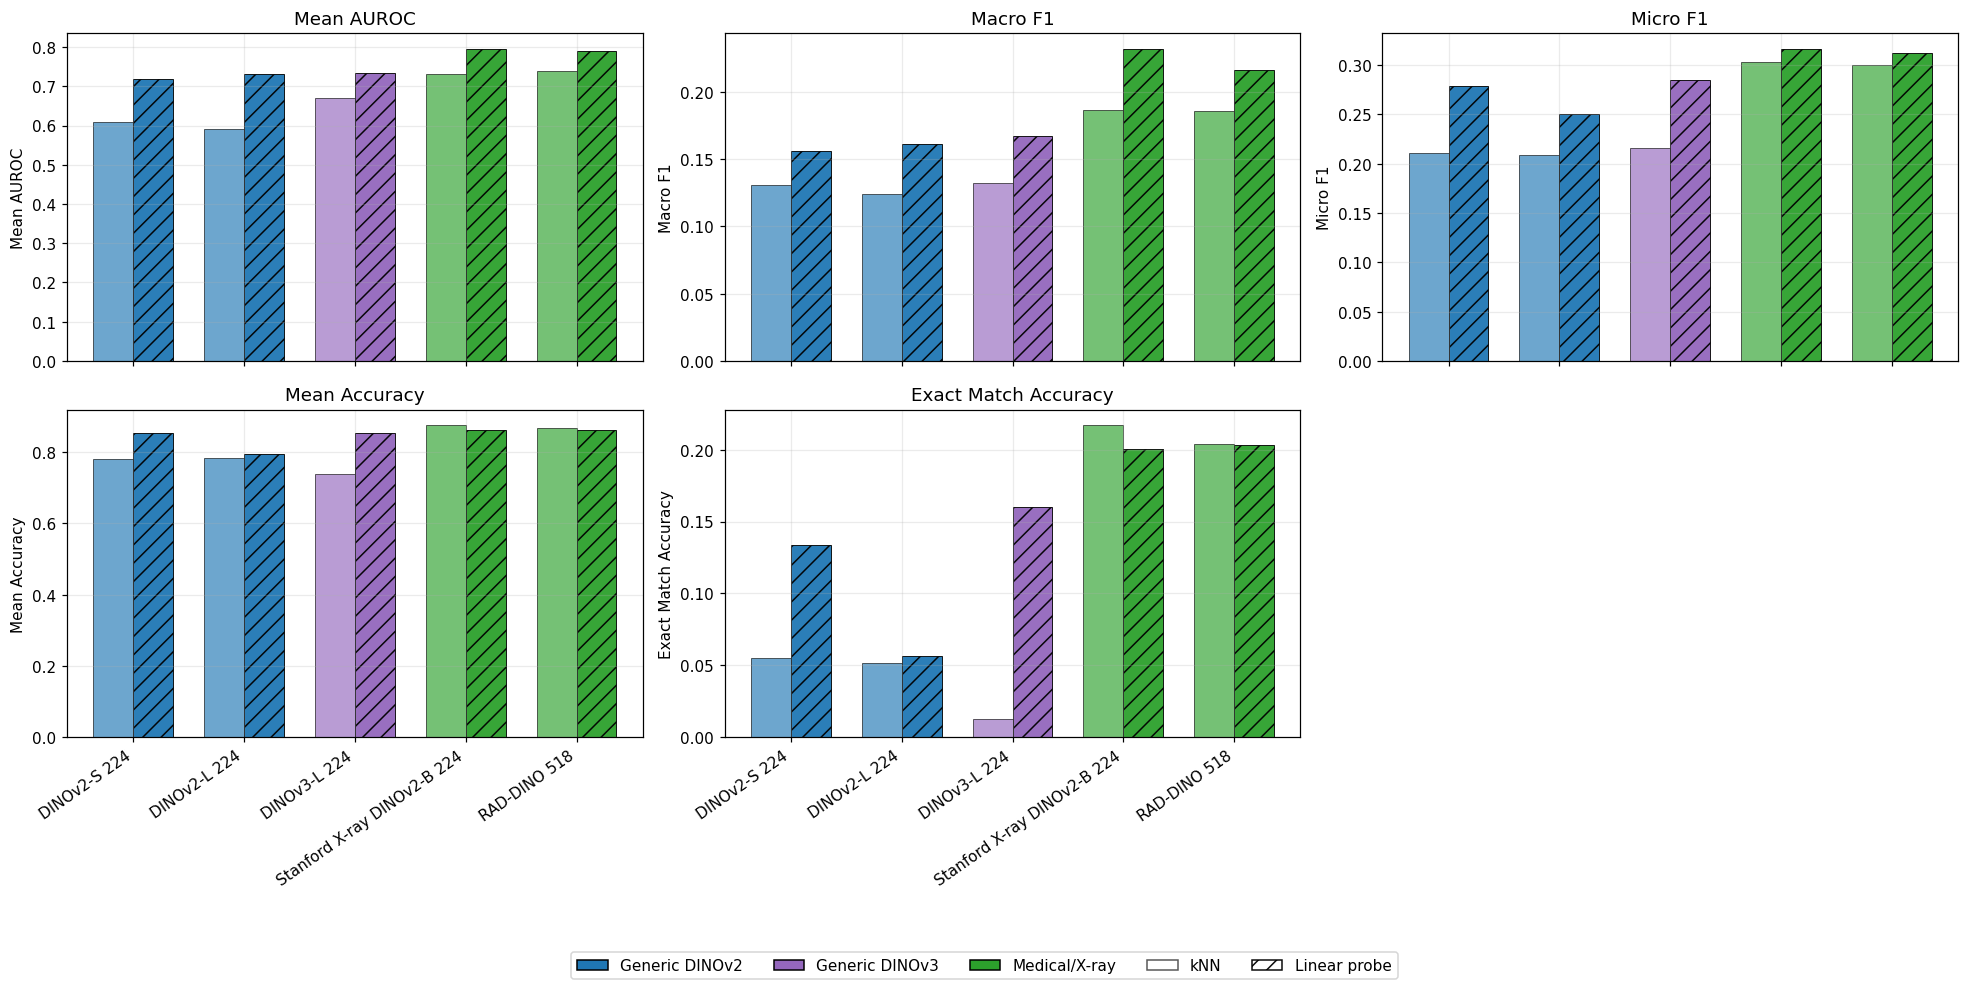

In [4]:
metrics_to_plot = [
    ("mean_auc", "Mean AUROC"),
    ("f1_macro", "Macro F1"),
    ("f1_micro", "Micro F1"),
    ("mean_accuracy", "Mean Accuracy"),
    ("exact_match_accuracy", "Exact Match Accuracy"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
axes = axes.ravel()
x = np.arange(len(model_order))
width = 0.36

for ax, (metric, title) in zip(axes, metrics_to_plot):
    for method_idx, method in enumerate(["kNN", "Linear probe"]):
        method_df = headline_df[headline_df["method"] == method].set_index("run_name").loc[model_order]
        offset = (-0.5 if method_idx == 0 else 0.5) * width
        colors = [group_colors[model_groups[name]] for name in model_order]
        ax.bar(
            x + offset,
            method_df[metric],
            width=width,
            color=colors,
            alpha=0.65 if method == "kNN" else 0.95,
            edgecolor="black",
            linewidth=0.6,
            hatch=method_hatches[method],
        )
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.set_xticks(x)
    ax.set_xticklabels([display_names[name] for name in model_order], rotation=35, ha="right")

axes[-1].axis("off")
legend_items = [
    Patch(facecolor=group_colors[group], edgecolor="black", label=group)
    for group in group_colors
] + [
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch=method_hatches[method],
        alpha=0.65 if method == "kNN" else 0.95,
        label=method,
    )
    for method in ["kNN", "Linear probe"]
]
fig.legend(handles=legend_items, loc="lower center", ncol=5)
fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## Paired Method Deltas

Positive performance deltas favor linear probing. Efficiency ratios above one mean
linear probing used more of that resource than kNN.

In [5]:
performance_metrics = ["mean_auc", "f1_macro", "f1_micro", "mean_accuracy", "exact_match_accuracy"]
efficiency_metrics = ["efficiency_counted_seconds", "actual_wall_seconds", "peak_gpu_memory_mb"]

wide_df = headline_df.pivot(index="run_name", columns="method")
delta_df = pd.DataFrame(index=model_order)
delta_df.index.name = "run_name"
delta_df["display_name"] = [display_names[name] for name in model_order]

for metric in performance_metrics:
    delta_df[f"{metric}_delta"] = (
        wide_df[(metric, "Linear probe")] - wide_df[(metric, "kNN")]
    ).reindex(model_order)

for metric in efficiency_metrics:
    delta_df[f"{metric}_ratio"] = (
        wide_df[(metric, "Linear probe")] / wide_df[(metric, "kNN")]
    ).reindex(model_order)

delta_df

,display_name,mean_auc_delta,f1_macro_delta,f1_micro_delta,mean_accuracy_delta,exact_match_accuracy_delta,efficiency_counted_seconds_ratio,actual_wall_seconds_ratio,peak_gpu_memory_mb_ratio
run_name,,,,,,,,,
dinov2_small_224,DINOv2-S 224,0.109817,0.024608,0.068088,0.073504,0.078349,3.271845,4.868972,0.854985
dinov2_large_224,DINOv2-L 224,0.138098,0.037051,0.041891,0.011282,0.004902,1.757284,2.270516,1.005564
dinov3_large_224,DINOv3-L 224,0.065024,0.035142,0.069379,0.115264,0.147161,1.809632,2.406895,1.006036
stanford_dinov2_xray_224,Stanford X-ray DINOv2-B 224,0.062815,0.045044,0.013132,-0.013313,-0.016757,2.439996,3.543088,1.015474
rad_dino_518,RAD-DINO 518,0.051965,0.030420,0.012514,-0.004692,-0.000713,1.365936,1.649961,1.009899


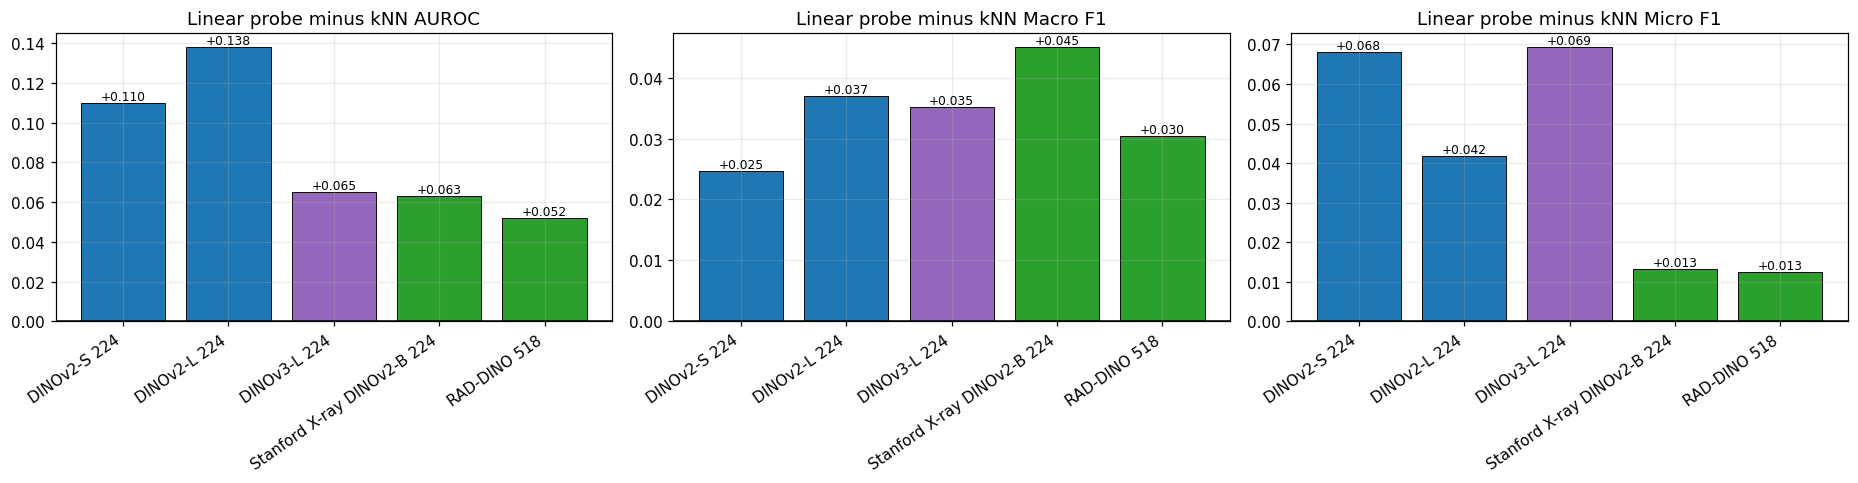

In [6]:
delta_specs = [
    ("mean_auc_delta", "Linear probe minus kNN AUROC"),
    ("f1_macro_delta", "Linear probe minus kNN Macro F1"),
    ("f1_micro_delta", "Linear probe minus kNN Micro F1"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharex=True)
colors = [group_colors[model_groups[name]] for name in model_order]
for ax, (column, title) in zip(axes, delta_specs):
    values = delta_df.loc[model_order, column]
    ax.bar(np.arange(len(model_order)), values, color=colors, edgecolor="black", linewidth=0.6)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(model_order)))
    ax.set_xticklabels([display_names[name] for name in model_order], rotation=35, ha="right")
    for idx, value in enumerate(values):
        ax.text(idx, value, f"{value:+.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

## Performance vs Efficiency

Colors preserve the generic-versus-medical model grouping. Marker shape identifies
the adaptation method.

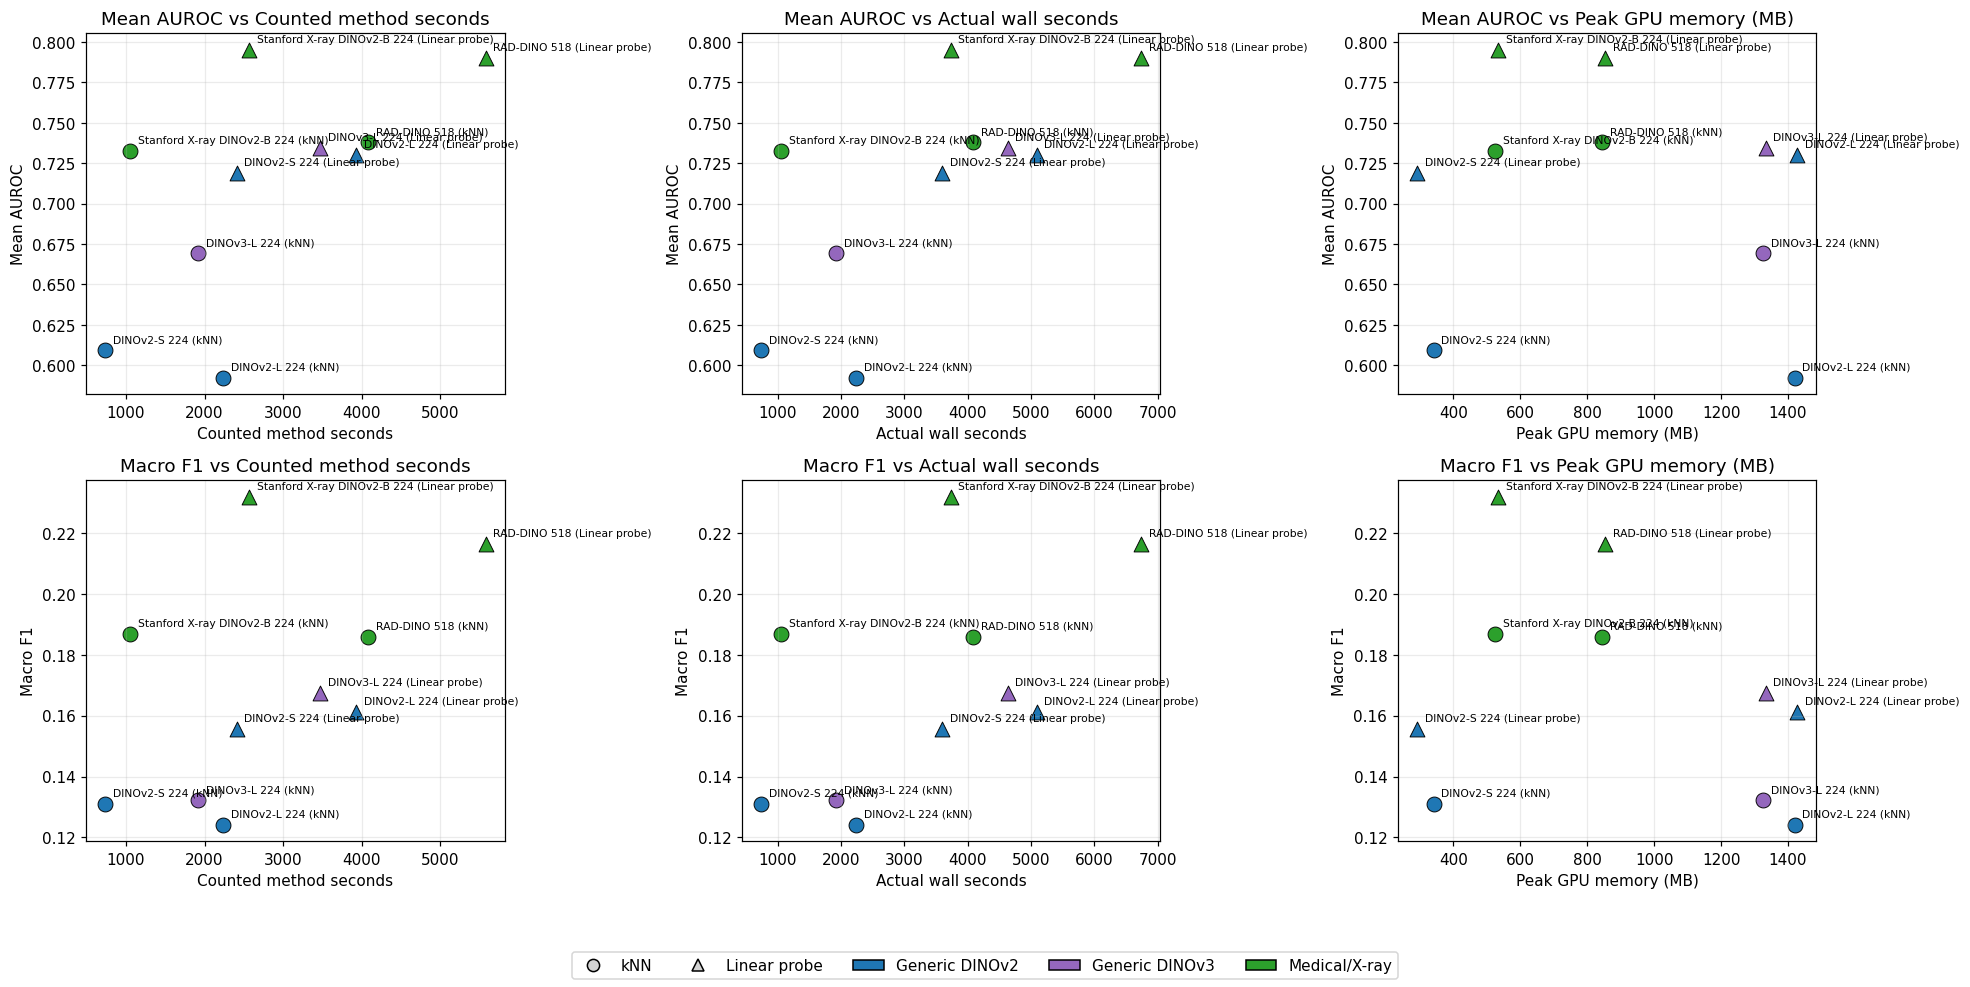

In [7]:
scatter_specs = [
    ("efficiency_counted_seconds", "Counted method seconds"),
    ("actual_wall_seconds", "Actual wall seconds"),
    ("peak_gpu_memory_mb", "Peak GPU memory (MB)"),
]
metric_specs = [("mean_auc", "Mean AUROC"), ("f1_macro", "Macro F1")]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for row_idx, (metric, metric_title) in enumerate(metric_specs):
    for ax, (x_col, x_title) in zip(axes[row_idx], scatter_specs):
        for _, row in headline_df.iterrows():
            ax.scatter(
                row[x_col],
                row[metric],
                s=95,
                marker=method_markers[row["method"]],
                color=group_colors[row["model_group"]],
                edgecolor="black",
                linewidth=0.6,
            )
            ax.annotate(
                f'{row["display_name"]} ({row["method"]})',
                (row[x_col], row[metric]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=7,
            )
        ax.set_title(f"{metric_title} vs {x_title}")
        ax.set_xlabel(x_title)
        ax.set_ylabel(metric_title)

legend_items = [
    Line2D([0], [0], marker=method_markers[method], color="none", markeredgecolor="black",
           markerfacecolor="lightgray", markersize=8, label=method)
    for method in method_markers
] + [
    Patch(facecolor=color, edgecolor="black", label=group)
    for group, color in group_colors.items()
]
fig.legend(handles=legend_items, loc="lower center", ncol=5)
fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## Timing Composition and Audit

The stacked bars use the explicitly counted phases. `Uncounted wall seconds` is the
difference between actual notebook wall time and the sum of those phases; it can include
model/data loading, Python bookkeeping, plotting/output overhead, and synchronization.

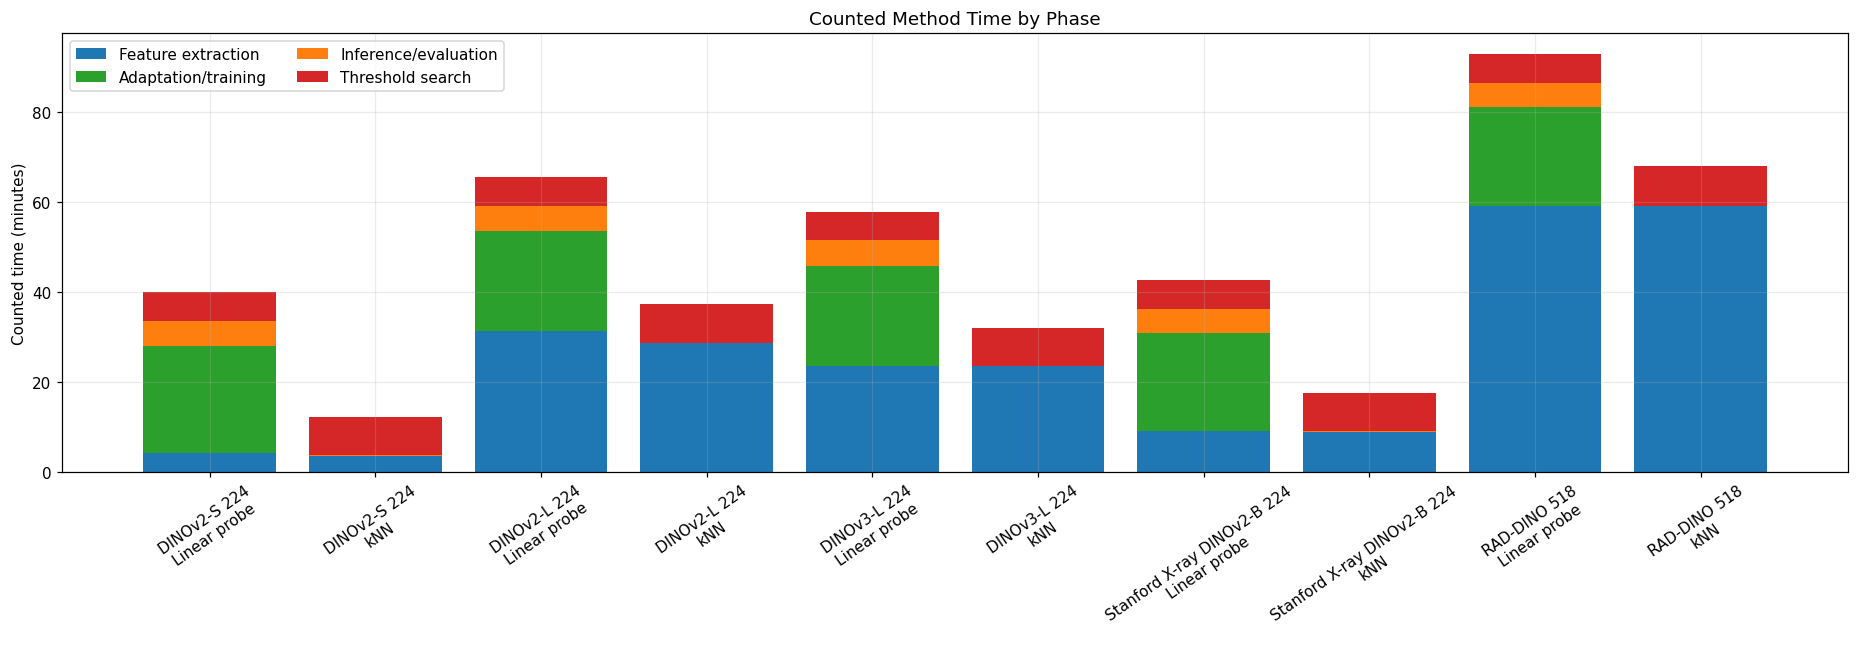

,display_name,method,feature_extraction_seconds,adaptation_seconds,inference_or_eval_seconds,threshold_search_seconds,counted_phase_sum_seconds,efficiency_counted_seconds,actual_wall_seconds,unaccounted_wall_seconds
1,DINOv2-S 224,Linear probe,256.011025,1420.507912,343.948532,389.416481,2409.883950,2409.883950,3597.922648,1188.038697
0,DINOv2-S 224,kNN,221.035093,0.000000,4.781057,510.735899,736.552050,736.552050,738.949197,2.397148
3,DINOv2-L 224,Linear probe,1879.042324,1337.438334,334.689348,382.904081,3934.074088,3934.074088,5088.123292,1154.049204
2,DINOv2-L 224,kNN,1716.486026,0.000000,6.075068,516.163626,2238.724719,2238.724719,2240.954770,2.230052
5,DINOv3-L 224,Linear probe,1413.694042,1341.511145,338.178100,383.552481,3476.935769,3476.935769,4629.586975,1152.651207
4,DINOv3-L 224,kNN,1409.468066,0.000000,5.639757,506.241831,1921.349654,1921.349654,1923.468393,2.118739
7,Stanford X-ray DINOv2-B 224,Linear probe,542.725509,1309.717230,326.329949,386.486891,2565.259578,2565.259578,3730.824554,1165.564976
6,Stanford X-ray DINOv2-B 224,kNN,539.310749,0.000000,5.027926,506.998970,1051.337644,1051.337644,1052.986774,1.649129
9,RAD-DINO 518,Linear probe,3555.353408,1312.373551,327.675739,383.831073,5579.233771,5579.233771,6742.395618,1163.161847
8,RAD-DINO 518,kNN,3550.772442,0.000000,5.635074,528.143386,4084.550902,4084.550902,4086.396746,1.845844


In [8]:
phase_cols = [
    "feature_extraction_seconds",
    "adaptation_seconds",
    "inference_or_eval_seconds",
    "threshold_search_seconds",
]
phase_labels = ["Feature extraction", "Adaptation/training", "Inference/evaluation", "Threshold search"]
phase_colors = ["tab:blue", "tab:green", "tab:orange", "tab:red"]

timing_df = headline_df.sort_values(["model_order", "method"]).copy()
timing_df["counted_phase_sum_seconds"] = timing_df[phase_cols].sum(axis=1)
timing_df["unaccounted_wall_seconds"] = (
    timing_df["actual_wall_seconds"] - timing_df["counted_phase_sum_seconds"]
)
timing_df["label"] = timing_df["display_name"] + "\n" + timing_df["method"]

fig, ax = plt.subplots(figsize=(17, 6))
bottom = np.zeros(len(timing_df))
for column, label, color in zip(phase_cols, phase_labels, phase_colors):
    values = timing_df[column].to_numpy() / 60
    ax.bar(timing_df["label"], values, bottom=bottom, label=label, color=color)
    bottom += values
ax.set_ylabel("Counted time (minutes)")
ax.set_title("Counted Method Time by Phase")
ax.tick_params(axis="x", rotation=35)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

timing_df[
    [
        "display_name",
        "method",
        *phase_cols,
        "counted_phase_sum_seconds",
        "efficiency_counted_seconds",
        "actual_wall_seconds",
        "unaccounted_wall_seconds",
    ]
]

## Per-Class Linear-Probe Gain over kNN

Each cell is linear probe minus kNN for the selected configuration. Positive values
favor linear probing; negative values favor kNN.

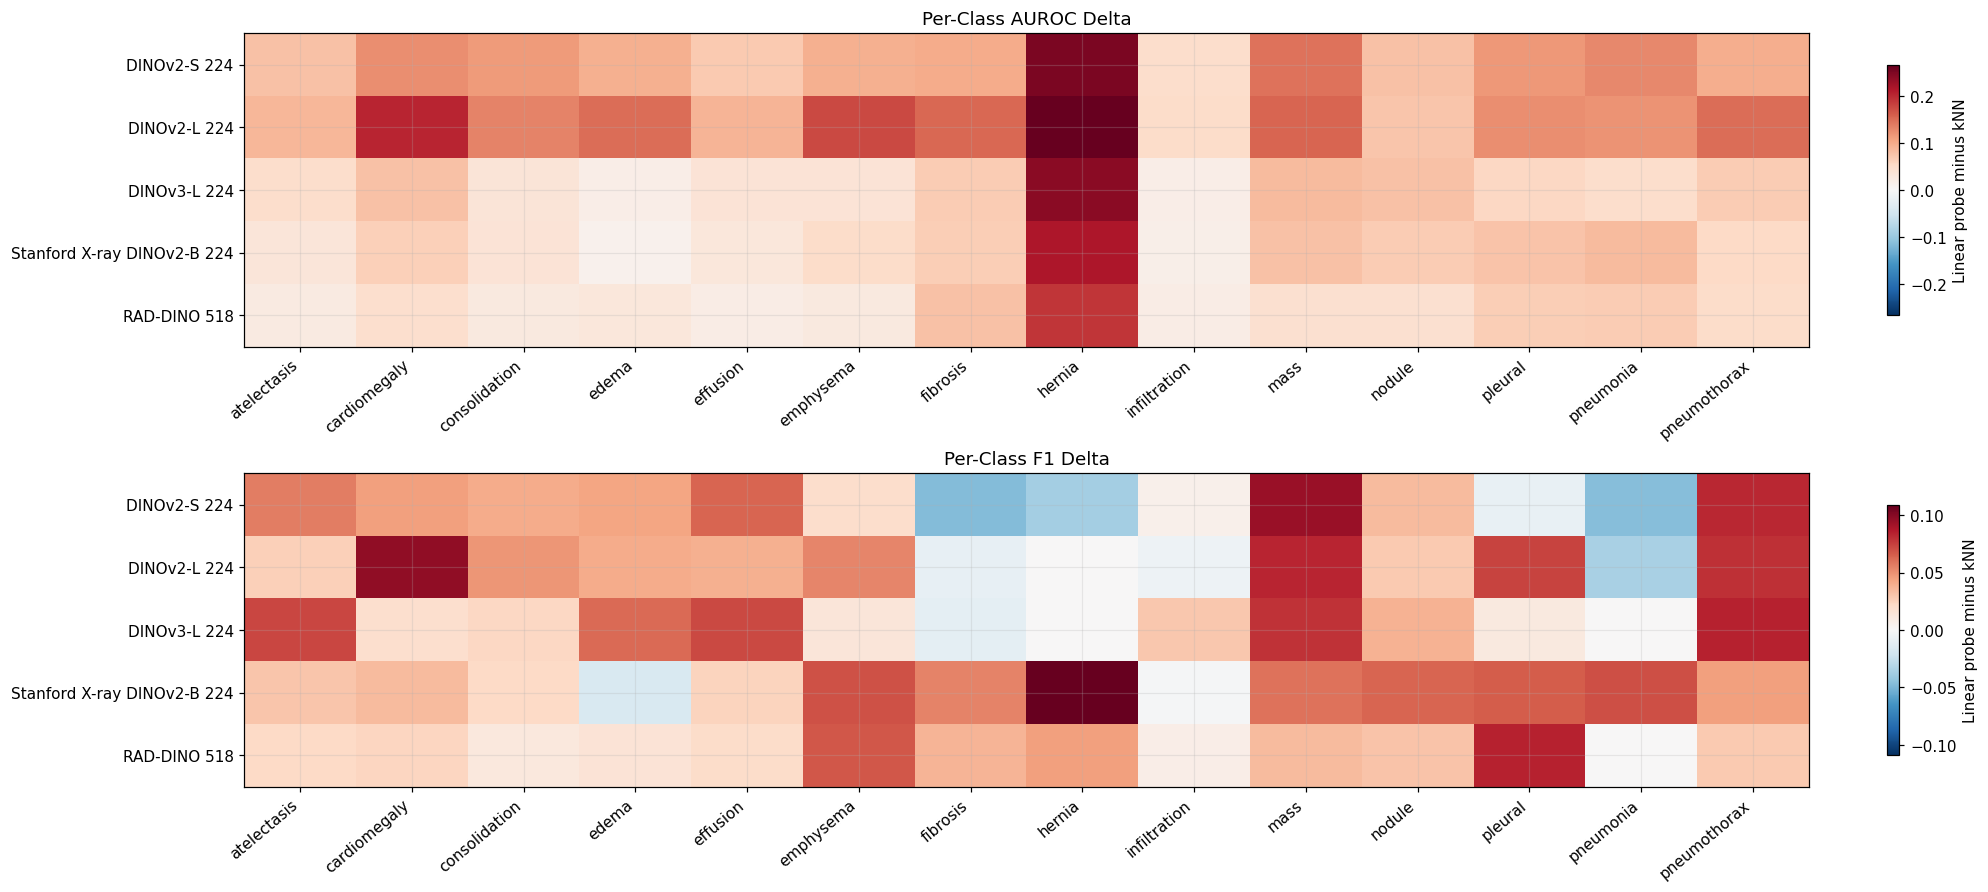

,run_name,class_name,auc_delta,f1_delta,display_name
49,stanford_dinov2_xray_224,hernia,0.215377,0.109091,Stanford X-ray DINOv2-B 224
15,dinov2_large_224,cardiomegaly,0.202301,0.096533,DINOv2-L 224
9,dinov2_small_224,mass,0.144653,0.093858,DINOv2-S 224
41,dinov3_large_224,pneumothorax,0.068467,0.084221,DINOv3-L 224
67,rad_dino_518,pleural,0.064716,0.083765,RAD-DINO 518
23,dinov2_large_224,mass,0.155638,0.083484,DINOv2-L 224
13,dinov2_small_224,pneumothorax,0.097762,0.082531,DINOv2-S 224
27,dinov2_large_224,pneumothorax,0.149625,0.079571,DINOv2-L 224
37,dinov3_large_224,mass,0.083662,0.079226,DINOv3-L 224
25,dinov2_large_224,pleural,0.125108,0.073682,DINOv2-L 224


In [9]:
class_order = sorted(per_class_df["class_name"].unique())
per_class_wide = per_class_df.pivot_table(
    index=["run_name", "class_name"],
    columns="method",
    values=["f1", "auc"],
    aggfunc="first",
)

f1_delta = (
    per_class_wide[("f1", "Linear probe")] - per_class_wide[("f1", "kNN")]
).unstack("class_name").reindex(index=model_order, columns=class_order)
auc_delta = (
    per_class_wide[("auc", "Linear probe")] - per_class_wide[("auc", "kNN")]
).unstack("class_name").reindex(index=model_order, columns=class_order)

fig, axes = plt.subplots(2, 1, figsize=(18, 8), constrained_layout=True)
for ax, data, title in [
    (axes[0], auc_delta, "Per-Class AUROC Delta"),
    (axes[1], f1_delta, "Per-Class F1 Delta"),
]:
    limit = np.nanmax(np.abs(data.to_numpy()))
    image = ax.imshow(data, aspect="auto", cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit))
    ax.set_title(title)
    ax.set_yticks(np.arange(len(model_order)))
    ax.set_yticklabels([display_names[name] for name in model_order])
    ax.set_xticks(np.arange(len(class_order)))
    ax.set_xticklabels(class_order, rotation=40, ha="right")
    fig.colorbar(image, ax=ax, shrink=0.8, label="Linear probe minus kNN")
plt.show()

per_class_delta_table_df = pd.concat(
    {"auc_delta": auc_delta.stack(), "f1_delta": f1_delta.stack()},
    axis=1,
).reset_index()
per_class_delta_table_df["display_name"] = per_class_delta_table_df["run_name"].map(display_names)
per_class_delta_table_df.sort_values("f1_delta", ascending=False).head(20)

## Within-Method Selection Diagnostics

These plots audit each method's search space; their x-axes are method-specific and are
not meant as a direct k-versus-epoch comparison.

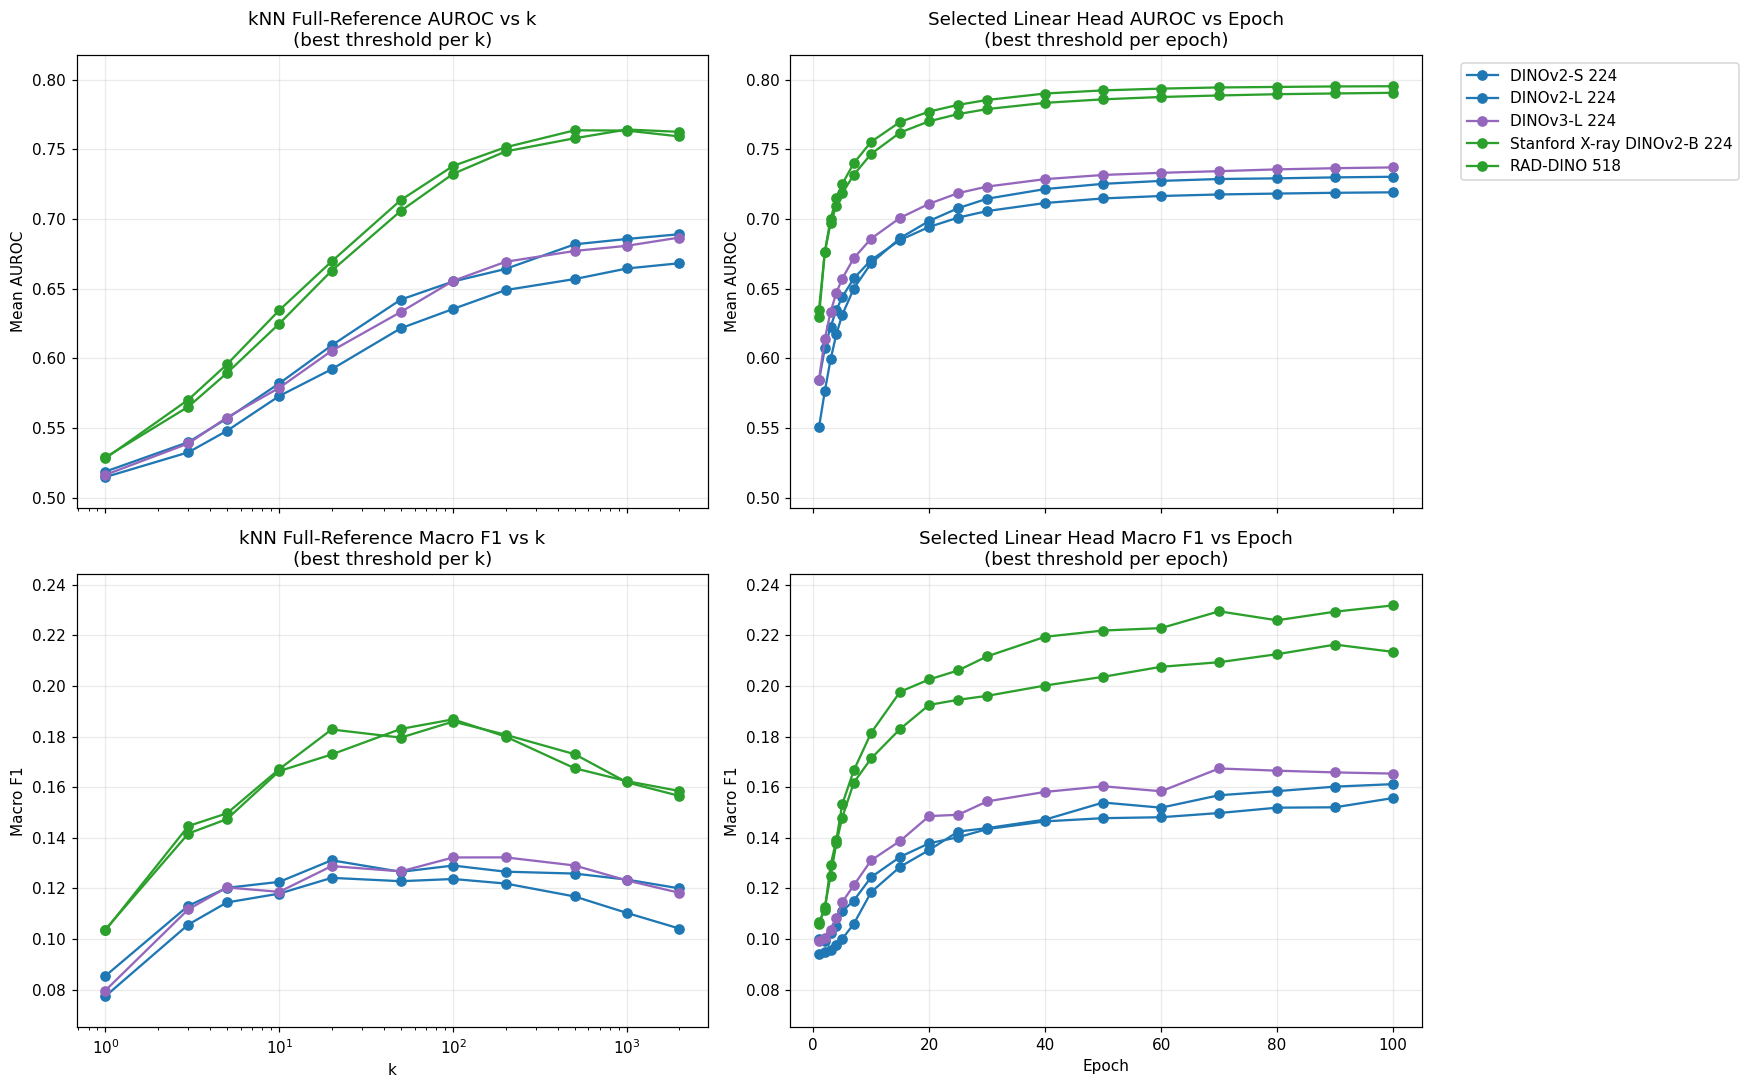

In [10]:
knn_best_threshold_per_k = (
    knn_full_grid_df.sort_values(
        ["run_name", "k", "f1_macro_mean", "mean_auc_mean"],
        ascending=[True, True, False, False],
    )
    .groupby(["run_name", "k"], as_index=False)
    .head(1)
)

linear_selected_curves = []
for run_name in model_order:
    selected_trial = metadata_df.loc[
        (metadata_df["run_name"] == run_name) & (metadata_df["method"] == "Linear probe"),
        "selected_train_trial_id",
    ].iloc[0]
    selected_trials = linear_trials_df[
        (linear_trials_df["run_name"] == run_name)
        & (linear_trials_df["train_trial_id"] == selected_trial)
    ]
    selected_trials = (
        selected_trials.sort_values(
            ["epoch", "f1_macro", "mean_auc"],
            ascending=[True, False, False],
        )
        .groupby("epoch", as_index=False)
        .head(1)
    )
    linear_selected_curves.append(selected_trials)
linear_selected_curve_df = pd.concat(linear_selected_curves, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex="col")
for run_name in model_order:
    color = group_colors[model_groups[run_name]]
    knn_df = knn_best_threshold_per_k[knn_best_threshold_per_k["run_name"] == run_name].sort_values("k")
    linear_df = linear_selected_curve_df[linear_selected_curve_df["run_name"] == run_name].sort_values("epoch")
    axes[0, 0].plot(knn_df["k"], knn_df["mean_auc_mean"], marker="o", color=color, label=display_names[run_name])
    axes[0, 1].plot(linear_df["epoch"], linear_df["mean_auc"], marker="o", color=color, label=display_names[run_name])
    axes[1, 0].plot(knn_df["k"], knn_df["f1_macro_mean"], marker="o", color=color, label=display_names[run_name])
    axes[1, 1].plot(linear_df["epoch"], linear_df["f1_macro"], marker="o", color=color, label=display_names[run_name])

axes[0, 0].set_xscale("log")
axes[1, 0].set_xscale("log")
axes[0, 0].set_title("kNN Full-Reference AUROC vs k\n(best threshold per k)")
axes[0, 1].set_title("Selected Linear Head AUROC vs Epoch\n(best threshold per epoch)")
axes[1, 0].set_title("kNN Full-Reference Macro F1 vs k\n(best threshold per k)")
axes[1, 1].set_title("Selected Linear Head Macro F1 vs Epoch\n(best threshold per epoch)")
axes[0, 0].set_ylabel("Mean AUROC")
axes[0, 1].set_ylabel("Mean AUROC")
axes[1, 0].set_ylabel("Macro F1")
axes[1, 1].set_ylabel("Macro F1")
axes[1, 0].set_xlabel("k")
axes[1, 1].set_xlabel("Epoch")

def shared_limits(*series):
    values = np.concatenate([values.dropna().to_numpy() for values in series])
    value_range = values.max() - values.min()
    padding = max(value_range * 0.08, 0.01)
    return values.min() - padding, values.max() + padding

auc_limits = shared_limits(
    knn_best_threshold_per_k["mean_auc_mean"],
    linear_selected_curve_df["mean_auc"],
)
f1_limits = shared_limits(
    knn_best_threshold_per_k["f1_macro_mean"],
    linear_selected_curve_df["f1_macro"],
)
for ax in axes[0]:
    ax.set_ylim(*auc_limits)
for ax in axes[1]:
    ax.set_ylim(*f1_limits)

axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
selected_hyperparameters_df = headline_df[
    ["display_name", "method", "k", "epoch", "lr", "weight_decay", "threshold", "mean_auc", "f1_macro"]
].sort_values(["method", "f1_macro"], ascending=[True, False])
selected_hyperparameters_df

,display_name,method,k,epoch,lr,weight_decay,threshold,mean_auc,f1_macro
7,Stanford X-ray DINOv2-B 224,Linear probe,NaN,100.0,0.003,0.00001,0.10,0.795279,0.231865
9,RAD-DINO 518,Linear probe,NaN,90.0,0.003,0.00010,0.10,0.790089,0.216366
5,DINOv3-L 224,Linear probe,NaN,70.0,0.003,0.00010,0.10,0.734347,0.167396
3,DINOv2-L 224,Linear probe,NaN,100.0,0.003,0.00100,0.07,0.730337,0.161204
1,DINOv2-S 224,Linear probe,NaN,100.0,0.003,0.00000,0.10,0.719180,0.155708
6,Stanford X-ray DINOv2-B 224,kNN,100.0,NaN,NaN,NaN,0.10,0.732464,0.186821
8,RAD-DINO 518,kNN,100.0,NaN,NaN,NaN,0.10,0.738123,0.185946
4,DINOv3-L 224,kNN,200.0,NaN,NaN,NaN,0.05,0.669323,0.132254
0,DINOv2-S 224,kNN,20.0,NaN,NaN,NaN,0.10,0.609363,0.131099
2,DINOv2-L 224,kNN,20.0,NaN,NaN,NaN,0.10,0.592239,0.124154


## Compact Takeaways

These statements are computed from the loaded result files, so they update if the
completed results are replaced.

In [12]:
performance_delta_cols = ["mean_auc_delta", "f1_macro_delta", "f1_micro_delta"]
takeaway_df = pd.DataFrame(
    {
        "quantity": [
            "Models where linear probe improves AUROC",
            "Models where linear probe improves macro F1",
            "Mean AUROC gain from linear probe",
            "Mean macro-F1 gain from linear probe",
            "Median counted-time ratio, linear/kNN",
            "Median wall-time ratio, linear/kNN",
        ],
        "value": [
            int((delta_df["mean_auc_delta"] > 0).sum()),
            int((delta_df["f1_macro_delta"] > 0).sum()),
            delta_df["mean_auc_delta"].mean(),
            delta_df["f1_macro_delta"].mean(),
            delta_df["efficiency_counted_seconds_ratio"].median(),
            delta_df["actual_wall_seconds_ratio"].median(),
        ],
    }
)
takeaway_df

,quantity,value
0,Models where linear probe improves AUROC,5.000000
1,Models where linear probe improves macro F1,5.000000
2,Mean AUROC gain from linear probe,0.085544
3,Mean macro-F1 gain from linear probe,0.034453
4,"Median counted-time ratio, linear/kNN",1.809632
5,"Median wall-time ratio, linear/kNN",2.406895
